# ERA5 Covariate Exploration

ERA5 is ECMWF's reanalysis dataset — gridded global climate data at 0.25° (~28 km) resolution, monthly.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 1. Open & inspect the files

In [3]:
ds_flux = xr.open_dataset('../../data/era5/data_stream-moda_stepType-avgad.nc')
ds_atm  = xr.open_dataset('../../data/era5/data_stream-moda_stepType-avgua.nc')

# The two files have slightly different timestamps (one at 06:00, one at 00:00).
# Floor both to midnight so merge() aligns them correctly on a shared time axis.
ds_flux = ds_flux.assign_coords(valid_time=ds_flux.valid_time.values.astype('datetime64[D]'))
ds_atm  = ds_atm.assign_coords(valid_time=ds_atm.valid_time.values.astype('datetime64[D]'))

ds = xr.merge([ds_flux, ds_atm])
ds

<xarray.Dataset> Size: 40MB
Dimensions:     (latitude: 141, longitude: 141, valid_time: 84)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    expver      (valid_time) <U4 1kB '0001' '0001' '0001' ... '0001' '0001'
  * valid_time  (valid_time) datetime64[s] 672B 2013-05-01 ... 2024-11-01
Data variables:
    tp          (valid_time, latitude, longitude) float32 7MB ...
    pev         (valid_time, latitude, longitude) float32 7MB ...
    t2m         (valid_time, latitude, longitude) float32 7MB ...
    skt         (valid_time, latitude, longitude) float32 7MB ...
    swvl1       (valid_time, latitude, longitude) float32 7MB ...
    lai_lv      (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-30T01:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# Dimensions and coordinate ranges
print("=== Dimensions ===")
print(dict(ds.dims))

print("\n=== Time ===")
print(f"  {len(ds.valid_time)} steps: {str(ds.valid_time.values[0])[:10]} → {str(ds.valid_time.values[-1])[:10]}")

print("\n=== Spatial coverage ===")
print(f"  Latitude:  {float(ds.latitude.min()):.2f} → {float(ds.latitude.max()):.2f}  ({len(ds.latitude)} grid cells)")
print(f"  Longitude: {float(ds.longitude.min()):.2f} → {float(ds.longitude.max()):.2f}  ({len(ds.longitude)} grid cells)")

print("\n=== Variables ===")
descriptions = {
    'tp':     'Total precipitation (m)',
    'pev':    'Potential evaporation (m)',
    't2m':    '2m temperature (K)',
    'skt':    'Skin temperature (K)',
    'swvl1':  'Volumetric soil water layer 1 (m³/m³)',
    'lai_lv': 'Leaf area index, low vegetation (m²/m²)',
}
for var, desc in descriptions.items():
    da = ds[var]
    print(f"  {var:8s}  shape={da.shape}  units: {desc}")

=== Dimensions ===
{'latitude': 141, 'longitude': 141, 'valid_time': 84}

=== Time ===
  84 steps: 2013-05-01 → 2024-11-01

=== Spatial coverage ===
  Latitude:  5.00 → 40.00  (141 grid cells)
  Longitude: 65.00 → 100.00  (141 grid cells)

=== Variables ===
  tp        shape=(84, 141, 141)  units: Total precipitation (m)
  pev       shape=(84, 141, 141)  units: Potential evaporation (m)
  t2m       shape=(84, 141, 141)  units: 2m temperature (K)
  skt       shape=(84, 141, 141)  units: Skin temperature (K)
  swvl1     shape=(84, 141, 141)  units: Volumetric soil water layer 1 (m³/m³)
  lai_lv    shape=(84, 141, 141)  units: Leaf area index, low vegetation (m²/m²)


/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_44993/269420639.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(dict(ds.dims))


## 2. Visualize spatial coverage

Plot one time step per variable to see the spatial pattern across India.

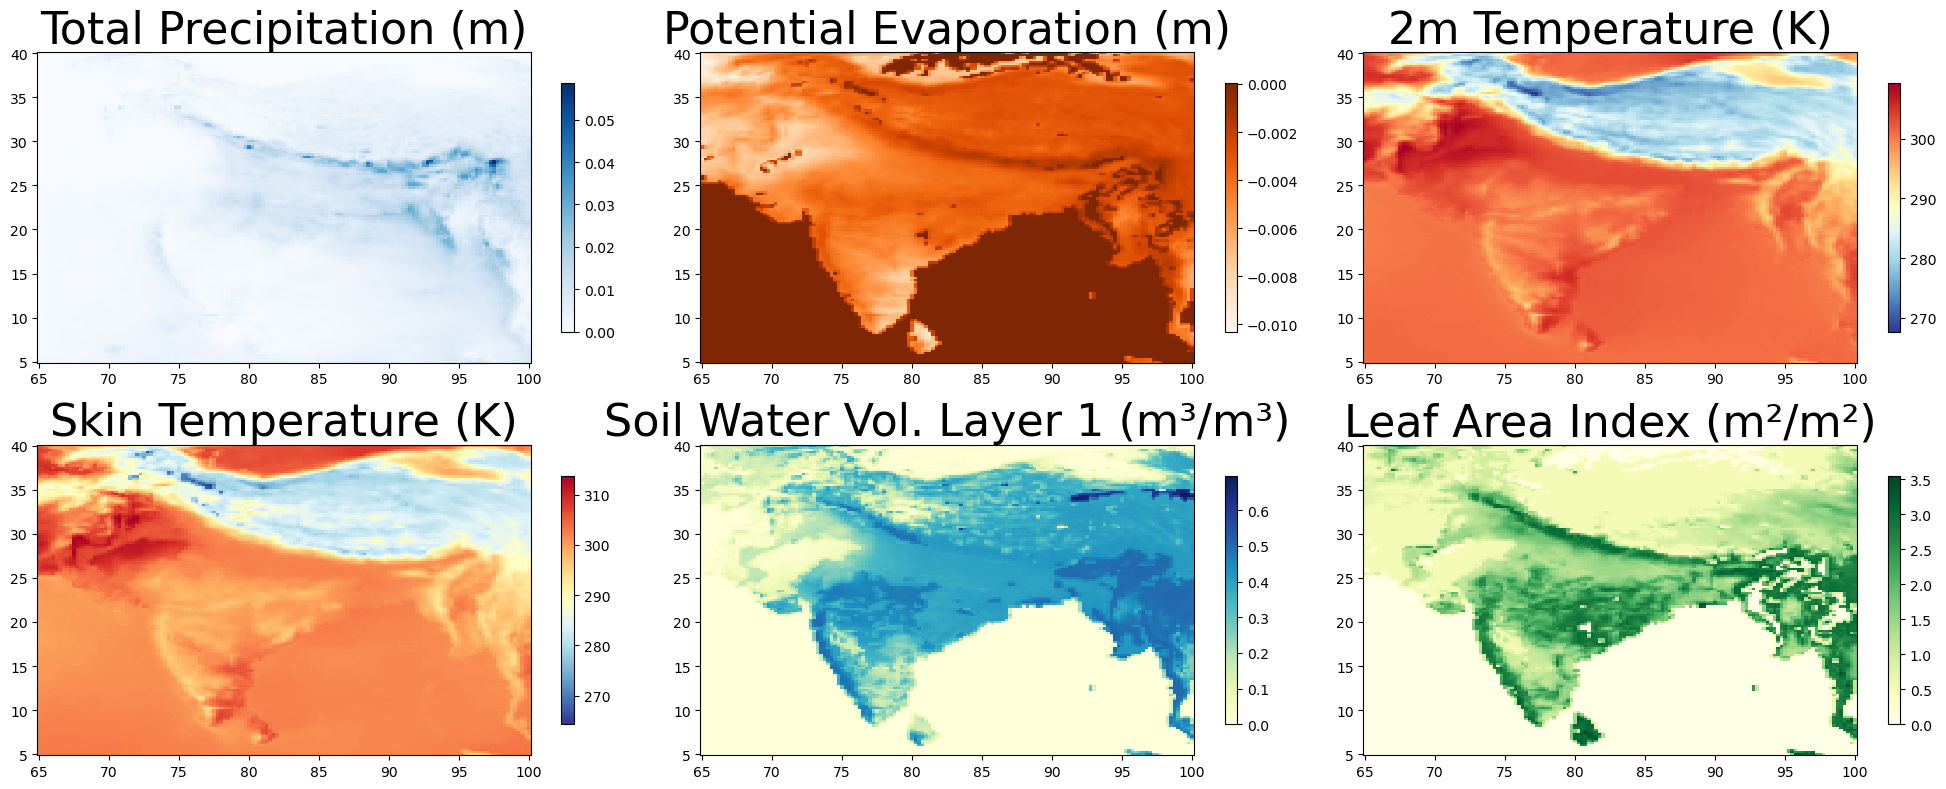

In [13]:
# Pick a single month to visualize: August 2023 (peak kharif growing season)
PLOT_MONTH = '2023-08'

variables = ['tp', 'pev', 't2m', 'skt', 'swvl1', 'lai_lv']
cmaps     = ['Blues', 'Oranges', 'RdYlBu_r', 'RdYlBu_r', 'YlGnBu', 'YlGn']
titles    = [
    'Total Precipitation (m)',
    'Potential Evaporation (m)',
    '2m Temperature (K)',
    'Skin Temperature (K)',
    'Soil Water Vol. Layer 1 (m³/m³)',
    'Leaf Area Index (m²/m²)',
]

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for ax, var, cmap, title in zip(axes.flat, variables, cmaps, titles):
    # .sel selects by coordinate label — xarray aligns on valid_time automatically
    snapshot = ds[var].sel(valid_time=PLOT_MONTH, method='nearest')
    im = ax.pcolormesh(ds.longitude, ds.latitude, snapshot, cmap=cmap)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{title}', fontsize=32)
    # ax.set_xlabel('Longitude')
    # ax.set_ylabel('Latitude')

# plt.suptitle('ERA5 Monthly Means – August 2023', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Time series for a single location

Before doing district-level aggregation, it's useful to sanity-check the temporal signal at one point. Let's pick a pixel near Ludhiana, Punjab.

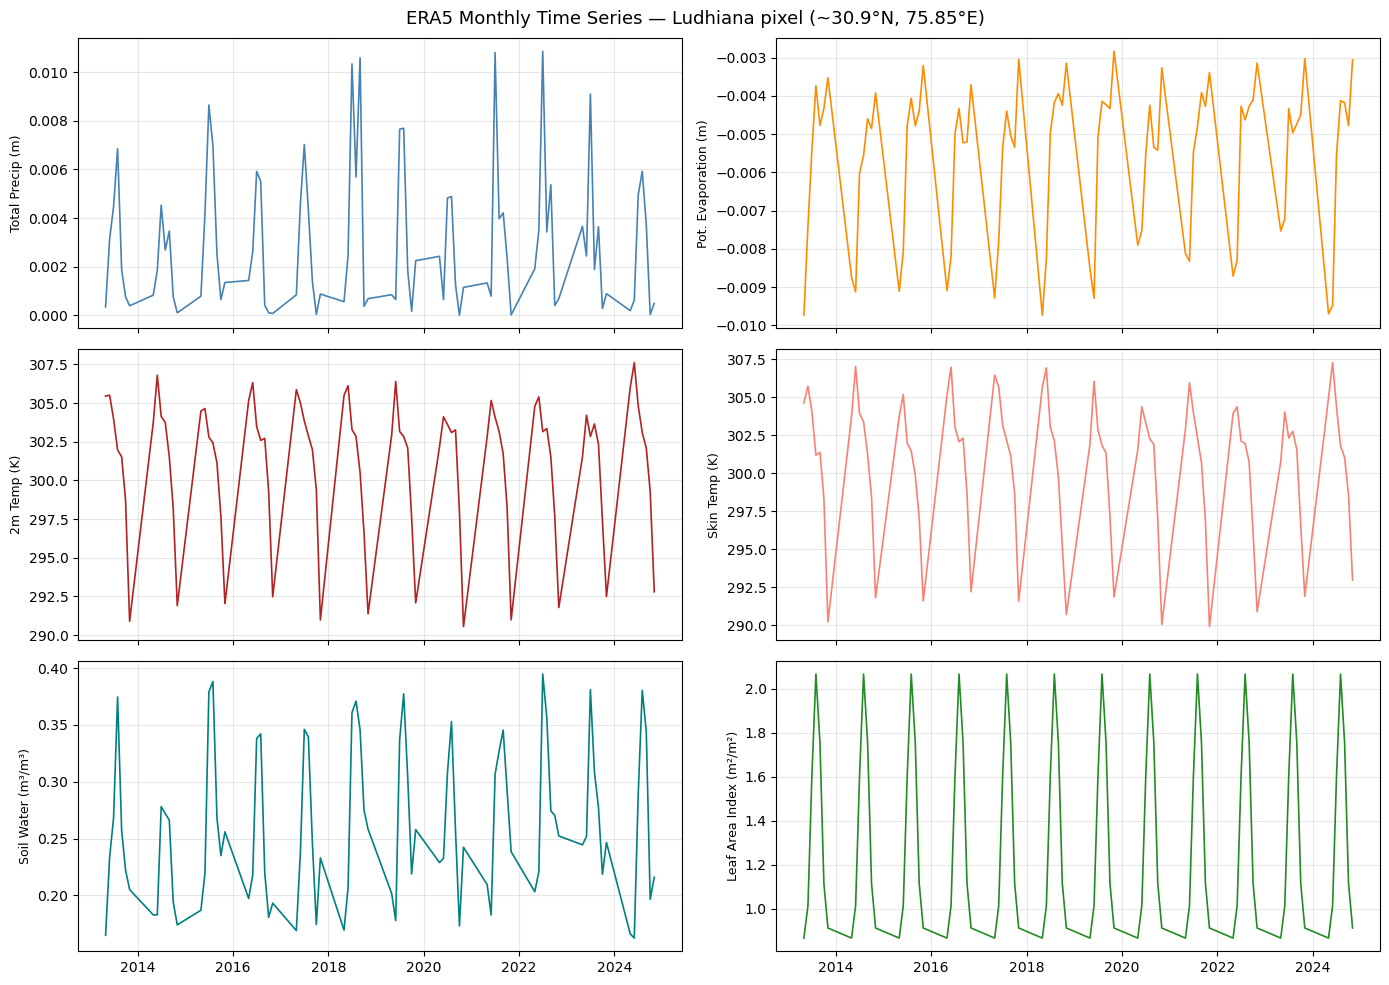

In [ ]:
# Ludhiana, Punjab ~ 30.9°N, 75.85°E
LAT, LON = 30.9, 75.85

# method='nearest' snaps to the closest grid point
point = ds.sel(latitude=LAT, longitude=LON, method='nearest')

times = pd.to_datetime(point.valid_time.values)


fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
plot_vars = [
    ('tp',    'Total Precip (m)',         'steelblue'),
    ('pev',   'Pot. Evaporation (m)',     'darkorange'),
    ('t2m',   '2m Temp (K)',              'firebrick'),
    ('skt',   'Skin Temp (K)',            'salmon'),
    ('swvl1', 'Soil Water (m³/m³)',       'teal'),
    ('lai_lv','Leaf Area Index (m²/m²)',  'forestgreen'),
]

for ax, (var, ylabel, color) in zip(axes.flat, plot_vars):
    ax.plot(times, point[var].values, color=color, linewidth=1.2)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'ERA5 Monthly Time Series — Ludhiana pixel (~{LAT}°N, {LON}°E)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. District-level spatial aggregation (Punjab)

For the model we need one value per district per month. Strategy: clip ERA5 to each district polygon → take the spatial mean. This gives us a `(districts × months × variables)` feature tensor.

In [ ]:
districts = gpd.read_file('data/punjab_districts_GAUL/Punjab_Districts_GAUL.shp').to_crs('EPSG:4326')
districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()
print(f"{len(districts)} districts loaded")
districts[['gaul2_name', 'geometry']].head()

22 districts loaded


,gaul2_name,geometry
0,Amritsar,"POLYGON ((74.48657 31.71511, 74.48704 31.71662..."
1,Barnala,"POLYGON ((75.25496 30.46492, 75.25856 30.47058..."
2,Bathinda,"POLYGON ((74.63078 30.12867, 74.64087 30.15121..."
3,Faridkot,"POLYGON ((74.46883 30.7451, 74.4689 30.74568, ..."
4,Fatehgarh Sahib,"POLYGON ((76.07758 30.54795, 76.08139 30.5578,..."


In [ ]:
from shapely.geometry import mapping

def era5_district_means(ds, districts, name_col='gaul2_name'):
    """
    For each district polygon, find all ERA5 grid cells whose centres fall inside,
    then take the mean across those cells for every time step.
    Returns a DataFrame with columns: district, valid_time, var1, var2, ...
    """
    lats = ds.latitude.values
    lons = ds.longitude.values
    # Build a meshgrid of all (lat, lon) centre coordinates
    lon_grid, lat_grid = np.meshgrid(lons, lats)  # shape (nlat, nlon)

    records = []
    for _, row in districts.iterrows():
        geom = row.geometry
        # Boolean mask: True where the grid cell centre is inside this district
        mask = np.array([
            geom.contains(__import__('shapely.geometry', fromlist=['Point']).Point(lo, la))
            for la, lo in zip(lat_grid.ravel(), lon_grid.ravel())
        ]).reshape(lat_grid.shape)

        if not mask.any():
            # Fallback: use the single nearest pixel to the centroid
            cx, cy = geom.centroid.x, geom.centroid.y
            ilat = int(np.argmin(np.abs(lats - cy)))
            ilon = int(np.argmin(np.abs(lons - cx)))
            mask[ilat, ilon] = True

        # Average over masked pixels for each time step
        for t_idx, t_val in enumerate(ds.valid_time.values):
            rec = {'district': row[name_col], 'valid_time': t_val}
            for var in ds.data_vars:
                vals = ds[var].values[t_idx][mask]
                rec[var] = float(np.nanmean(vals))
            records.append(rec)

    return pd.DataFrame(records)

print("Extracting ERA5 means per district")
era5_df = era5_district_means(ds, districts)
era5_df['valid_time'] = pd.to_datetime(era5_df['valid_time'])
era5_df['year']  = era5_df['valid_time'].dt.year
era5_df['month'] = era5_df['valid_time'].dt.month
print(f"Done. Shape: {era5_df.shape}")
era5_df.head(8)

Extracting ERA5 means per district
Done. Shape: (1848, 10)


,district,valid_time,tp,pev,t2m,skt,swvl1,lai_lv,year,month
0,Amritsar,2013-05-01,0.000666,-0.009551,305.805908,305.375519,0.169533,0.890381,2013,5
1,Amritsar,2013-06-01,0.007356,-0.007401,305.666504,305.776855,0.254484,1.046631,2013,6
2,Amritsar,2013-07-01,0.004320,-0.005356,304.206543,304.065430,0.281742,1.567261,2013,7
3,Amritsar,2013-08-01,0.008711,-0.003605,302.180664,301.383789,0.385427,1.922424,2013,8
4,Amritsar,2013-09-01,0.001537,-0.004648,301.469971,301.550354,0.257282,1.602356,2013,9
5,Amritsar,2013-10-01,0.000842,-0.004038,298.362183,298.092896,0.233544,1.166565,2013,10
6,Amritsar,2013-11-01,0.000481,-0.003088,290.507019,289.314575,0.217618,0.981384,2013,11
7,Amritsar,2014-05-01,0.001376,-0.008055,302.910400,302.834351,0.203149,0.890381,2014,5


## 5. Build the monthly feature table

Keep one row per district × year × month over the full kharif window: **May – November**.

In [ ]:
KHARIF_MONTHS = [5, 6, 7, 8, 9, 10, 11]  # May – November

kharif = era5_df[era5_df['month'].isin(KHARIF_MONTHS)].copy()

# Unit conversions (no aggregation — keep monthly resolution)
kharif['tp_mm']  = kharif['tp']  * 1000   # m → mm
kharif['pev_mm'] = kharif['pev'] * 1000
kharif['water_balance_mm'] = kharif['tp_mm'] + kharif['pev_mm']
kharif['t2m_c']  = kharif['t2m'] - 273.15  # K → °C

print(f"Monthly feature table shape: {kharif.shape}")
kharif[['district', 'year', 'month', 'tp_mm', 'pev_mm', 'water_balance_mm', 't2m_c', 'swvl1', 'lai_lv']].head(14)

Monthly feature table shape: (1848, 14)


,district,year,month,tp_mm,pev_mm,water_balance_mm,t2m_c,swvl1,lai_lv
0,Amritsar,2013,5,0.665665,-9.551406,-8.885741,32.655908,0.169533,0.890381
1,Amritsar,2013,6,7.355690,-7.401492,-0.045802,32.516504,0.254484,1.046631
2,Amritsar,2013,7,4.320145,-5.356070,-1.035925,31.056543,0.281742,1.567261
3,Amritsar,2013,8,8.710861,-3.604520,5.106341,29.030664,0.385427,1.922424
4,Amritsar,2013,9,1.537323,-4.648402,-3.111079,28.319971,0.257282,1.602356
5,Amritsar,2013,10,0.842094,-4.038490,-3.196396,25.212183,0.233544,1.166565
6,Amritsar,2013,11,0.480652,-3.087655,-2.607003,17.357019,0.217618,0.981384
7,Amritsar,2014,5,1.376152,-8.055370,-6.679218,29.760400,0.203149,0.890381
8,Amritsar,2014,6,1.931190,-9.284884,-7.353693,34.414453,0.168264,1.046631
9,Amritsar,2014,7,6.880760,-5.679466,1.201294,30.925195,0.316929,1.567261


## 6. Visualize monthly variability of key features

Plot each variable's monthly distribution across years and districts.

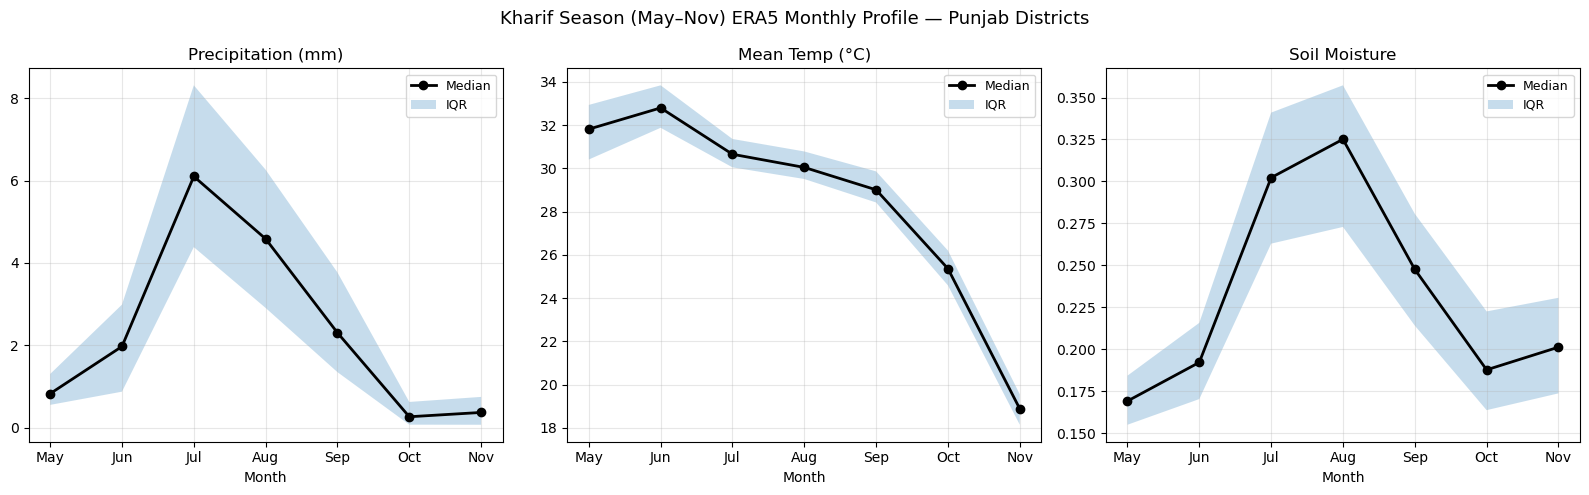

In [ ]:
import seaborn as sns

month_names = {5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, title in zip(axes, ['tp_mm', 't2m_c', 'swvl1'],
                                   ['Precipitation (mm)', 'Mean Temp (°C)', 'Soil Moisture']):
    monthly_median = kharif.groupby('month')[feat].median().rename(index=month_names)
    monthly_q25    = kharif.groupby('month')[feat].quantile(0.25).rename(index=month_names)
    monthly_q75    = kharif.groupby('month')[feat].quantile(0.75).rename(index=month_names)

    ax.plot(monthly_median.index, monthly_median.values, color='black', linewidth=2, marker='o', label='Median')
    ax.fill_between(monthly_median.index, monthly_q25.values, monthly_q75.values, alpha=0.25, label='IQR')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Month')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Kharif Season (May–Nov) ERA5 Monthly Profile — Punjab Districts', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Export for baseline model

Save the district × year feature matrix. This is the covariate table we'll join with the yield data when building the model.

In [ ]:
MODEL_FEATURES = ['tp_mm', 'pev_mm', 'water_balance_mm', 't2m_c', 'skt', 'swvl1', 'lai_lv']

output = kharif[['district', 'year', 'month'] + MODEL_FEATURES].sort_values(['district', 'year', 'month']).reset_index(drop=True)
output.to_csv('data/processed/era5_kharif_features_punjab.csv', index=False)
print(f"Saved {len(output)} rows × {len(output.columns)} cols")
print(output.describe().round(3))